In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
taipei = pd.read_csv("taipei.csv")

# IMPORTANT: use the correct column (already hourly!)
taipei['hour'] = pd.to_datetime(taipei['start_rental_date_hour'])

In [30]:
taipei.shape

(83239274, 9)

In [31]:
taipei_ts = taipei.groupby('hour').size()

print(taipei_ts.head())

hour
2017-01-01 00:00:00    3461
2017-01-01 01:00:00    3937
2017-01-01 02:00:00    2607
2017-01-01 03:00:00    1460
2017-01-01 04:00:00    1004
dtype: int64


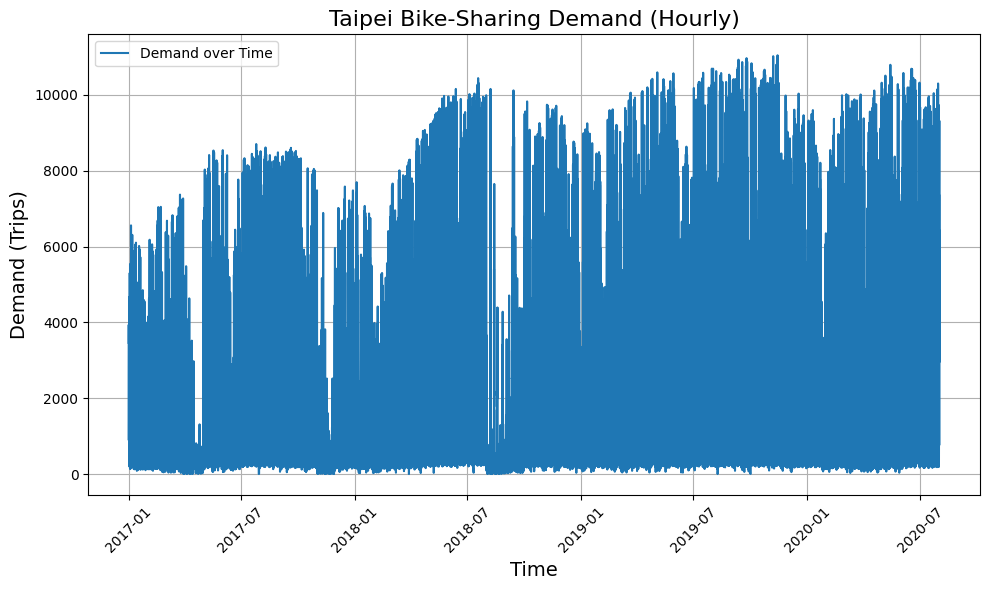

In [32]:
import matplotlib.pyplot as plt

# Plotting the time series for Taipei demand
plt.figure(figsize=(10,6))
plt.plot(taipei_ts.index, taipei_ts, label='Demand over Time', color='tab:blue')

plt.title('Taipei Bike-Sharing Demand (Hourly)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Demand (Trips)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.legend()
plt.show()

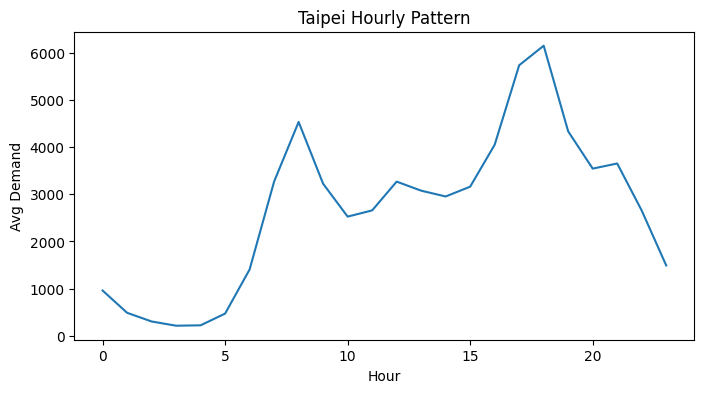

In [33]:
taipei_hourly = taipei_ts.groupby(taipei_ts.index.hour).mean()

plt.figure(figsize=(8,4))
plt.plot(taipei_hourly)
plt.title("Taipei Hourly Pattern")
plt.xlabel("Hour")
plt.ylabel("Avg Demand")
plt.show()

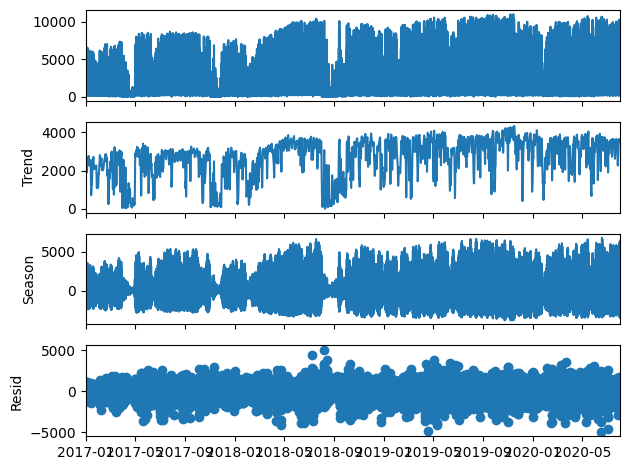

In [34]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

stl = STL(taipei_ts, period=24)
res = stl.fit()
res.plot()
plt.show()

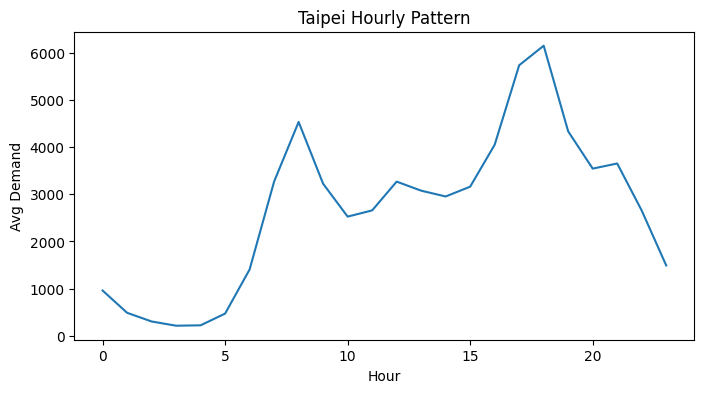

In [35]:
taipei_hourly = taipei_ts.groupby(taipei_ts.index.hour).mean()

plt.figure(figsize=(8,4))
plt.plot(taipei_hourly)
plt.title("Taipei Hourly Pattern")
plt.xlabel("Hour")
plt.ylabel("Avg Demand")
plt.show()

Linear RMSE: 1017.8974292889441
Random Forest RMSE: 495.4747703829901


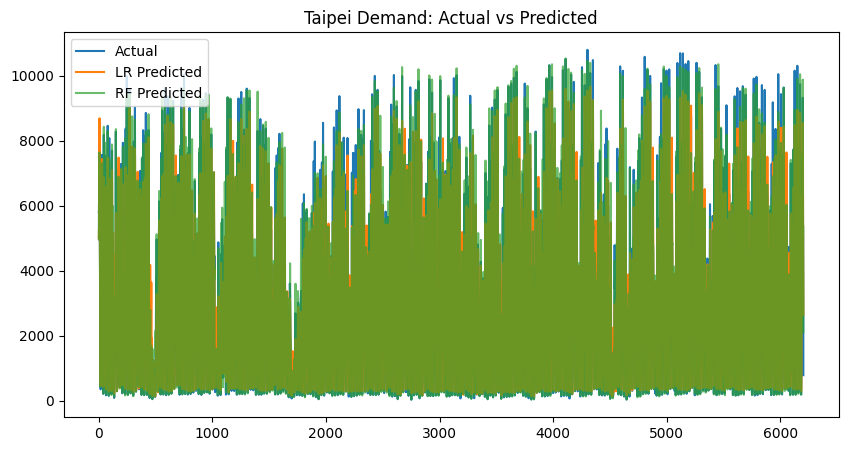

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# -------------------------------
# 1. Ensure datetime
# -------------------------------
taipei['hour'] = pd.to_datetime(taipei['start_rental_date_hour'], errors='coerce')
taipei = taipei.dropna(subset=['hour'])

# -------------------------------
# 2. Build time series
# -------------------------------
taipei_ts = taipei.groupby('hour').size().to_frame(name='count')

# -------------------------------
# 3. Feature Engineering
# -------------------------------

# lag features
taipei_ts['lag_1'] = taipei_ts['count'].shift(1)
taipei_ts['lag_24'] = taipei_ts['count'].shift(24)

# time features
taipei_ts['hour_of_day'] = taipei_ts.index.hour
taipei_ts['day_of_week'] = taipei_ts.index.dayofweek
taipei_ts['is_weekend'] = (taipei_ts.index.dayofweek >= 5).astype(int)

# drop NA from lags
taipei_ts = taipei_ts.dropna()

# -------------------------------
# 4. Train-Test Split (time-based)
# -------------------------------
split = int(len(taipei_ts) * 0.8)

train = taipei_ts.iloc[:split]
test  = taipei_ts.iloc[split:]

X_cols = ['lag_1', 'lag_24', 'hour_of_day', 'day_of_week', 'is_weekend']

X_train = train[X_cols]
y_train = train['count']

X_test = test[X_cols]
y_test = test['count']

# -------------------------------
# 5. Linear Regression
# -------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

# -------------------------------
# 6. Random Forest
# -------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

# -------------------------------
# 7. Print Results
# -------------------------------
print("Linear RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)

# -------------------------------
# 8. Plot (Actual vs Predicted)
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(pred_lr, label='LR Predicted')
plt.plot(pred_rf, label='RF Predicted', alpha=0.7)
plt.legend()
plt.title("Taipei Demand: Actual vs Predicted")
plt.show()

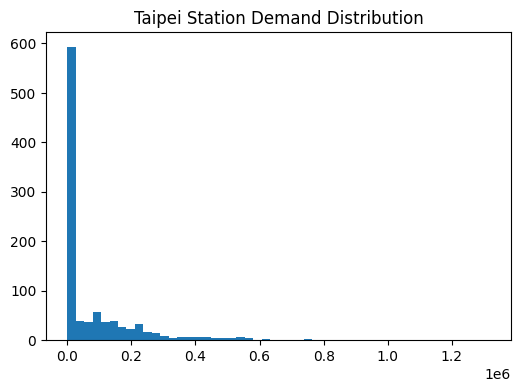

In [37]:
taipei_station = taipei.groupby('start_station_name_pinyin').size().reset_index(name='count')

plt.figure(figsize=(6,4))
plt.hist(taipei_station['count'], bins=50)
plt.title("Taipei Station Demand Distribution")
plt.show()

In [38]:
taipei_station['avg'] = taipei_station['count']


In [39]:
top = taipei_station.sort_values('avg', ascending=False).head(10)
print(top)

                 start_station_name_pinyin    count      avg
266         jieyungongguanzhan(2haochukou)  1318724  1318724
462                luosifuxinshengnanlukou  1070244  1070244
361          jieyunzhishanzhan(2haochukou)  1029617  1029617
315       jieyunshizhengfuzhan(3haochukou)   996727   996727
707                        taiwankejidaxue   875602   875602
702                        taidazixundalou   854612   854612
244                         jieyundaanzhan   818723   818723
284                    jieyunkejidalouzhan   747883   747883
320             jieyuntaibei101/shimaozhan   745509   745509
269  jieyunguofujinianguanzhan(2haochukou)   731889   731889
